In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

In [9]:
def load_and_preprocess(filepath):
    df = pd.read_csv(filepath)
    
    # Standard 49 columns to drop for project-wide consistency
    cols_to_drop = [
        "Fwd Packets Length Total", "Bwd Packets Length Total", "Fwd Packet Length Max", 
        "Bwd Packet Length Max", "Fwd Packet Length Min", "Bwd Packet Length Min",
        "Fwd Packet Length Std", "Bwd Packet Length Std", "Flow IAT Std", "Flow IAT Total",
        "Fwd IAT Std", "Fwd IAT Max", "Fwd IAT Min", "Bwd IAT Total", "Bwd IAT Std", 
        "Bwd IAT Max", "Bwd IAT Min", "Fwd PSH Flags", "Bwd PSH Flags", "Fwd URG Flags", 
        "Bwd URG Flags", "Packet Length Variance", "PSH Flag Count", "URG Flag Count", 
        "CWE Flag Count", "ECE Flag Count", "Down/Up Ratio", "Avg Packet Size",
        "Avg Fwd Segment Size", "Avg Bwd Segment Size", "Fwd Avg Bytes/Bulk", 
        "Fwd Avg Packets/Bulk", "Fwd Avg Bulk Rate", "Bwd Avg Bytes/Bulk", 
        "Bwd Avg Packets/Bulk", "Bwd Avg Bulk Rate", "Subflow Bwd Bytes",
        "Init Fwd Win Bytes", "Init Bwd Win Bytes", "Fwd Act Data Packets", 
        "Fwd Seg Size Min", "Active Mean", "Active Std", "Active Max", "Active Min",
        "Idle Mean", "Idle Std", "Idle Max", "Idle Min"
    ]
    df = df.drop(columns=cols_to_drop, axis=1, errors='ignore')
    df = df.replace([np.inf, -np.inf], np.nan).fillna(0)
    
    # Map Labels: 'Benign' -> 0, 'PortScan' -> 1
    df['Label'] = df['Label'].map({'Benign': 0, 'PortScan': 1})
    
    X = df.drop('Label', axis=1).values
    y = df['Label'].values
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    return train_test_split(X_scaled, y, test_size=0.2, stratify=y, random_state=42)

Training Random Forest on PortScan data...


C:\Users\Mohammad Saquib\AppData\Roaming\Python\Python312\site-packages\sklearn\ensemble\_forest.py:861: UserWarning: class_weight presets "balanced" or "balanced_subsample" are not recommended for warm_start if the fitted data differs from the full dataset. In order to use "balanced" weights, use compute_class_weight ("balanced", classes, y). In place of y you can use a large enough sample of the full training set target to properly estimate the class frequency distributions. Pass the resulting weights as the class_weight parameter.
  warn(



--- CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00     23514
    PortScan       1.00      0.99      1.00       391

    accuracy                           1.00     23905
   macro avg       1.00      1.00      1.00     23905
weighted avg       1.00      1.00      1.00     23905



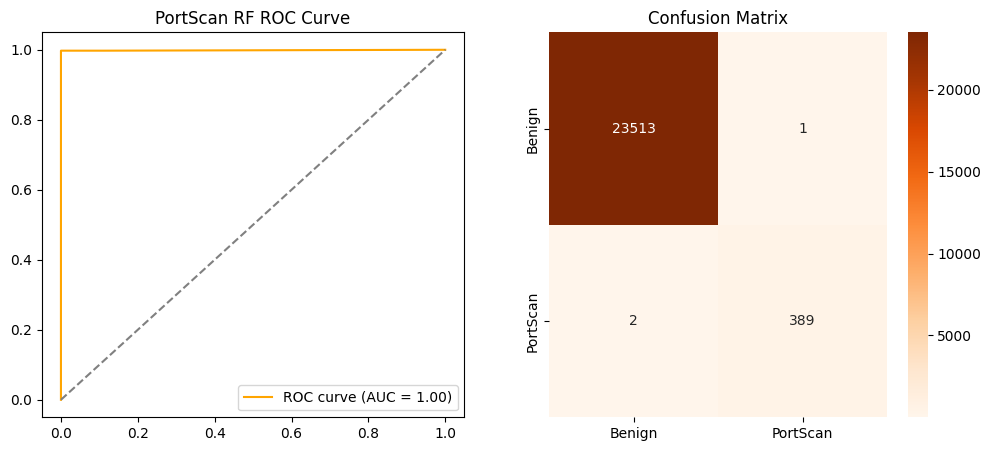

In [10]:
if __name__ == "__main__":
    # Load PortScan Dataset
    data_path = "C:\\Datasets\\IDS_Dataset\\Portscan-Friday-no-metadata.csv"
    X_train, X_test, y_train, y_test = load_and_preprocess(data_path)
    
    # --- STEP 3: Initialize Random Forest for FL ---
    # warm_start=True allows the ensemble to grow or update across rounds
    model = RandomForestClassifier(
        n_estimators=100, 
        warm_start=True, 
        max_depth=10, 
        min_samples_leaf=5,
        class_weight='balanced',
        random_state=42
    )
    
    # Local Training
    print("Training Random Forest on PortScan data...")
    model.fit(X_train, y_train)
    
    # --- STEP 4: Evaluation ---
    y_pred = model.predict(X_test)
    y_probs = model.predict_proba(X_test)[:, 1]
    
    # Classification Report
    print("\n--- CLASSIFICATION REPORT ---")
    print(classification_report(y_test, y_pred, target_names=['Benign', 'PortScan']))
    
    # ROC-AUC Calculation
    fpr, tpr, _ = roc_curve(y_test, y_probs)
    roc_auc = auc(fpr, tpr)
    
    # Plotting
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})', color='orange')
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
    plt.title('PortScan RF ROC Curve')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', xticklabels=['Benign', 'PortScan'], yticklabels=['Benign', 'PortScan'])
    plt.title('Confusion Matrix')
    plt.show()

In [11]:
from sklearn.model_selection import StratifiedKFold, cross_validate
import numpy as np

# 1. Define the Stratified K-Fold strategy (5 folds is standard)
# shuffle=True is critical to prevent bias if the CSV rows are ordered
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 2. Define the metrics we want to track
metrics = ['accuracy', 'precision', 'recall', 'f1']

print("Starting 5-Fold Cross-Validation...")

# 3. Perform the validation
# This trains and tests the model 5 separate times
cv_results = cross_validate(model, X_train, y_train, cv=skf, scoring=metrics)

# 4. Display the results for each fold
print("\n--- Cross-Validation Results ---")
for i in range(5):
    print(f"Fold {i+1}: Accuracy={cv_results['test_accuracy'][i]:.4f}, "
          f"F1-Score={cv_results['test_f1'][i]:.4f}")

print("-" * 30)
print(f"Mean Accuracy: {np.mean(cv_results['test_accuracy']):.4f}")
print(f"Mean F1-Score: {np.mean(cv_results['test_f1']):.4f}")

Starting 5-Fold Cross-Validation...


C:\Users\Mohammad Saquib\AppData\Roaming\Python\Python312\site-packages\sklearn\ensemble\_forest.py:861: UserWarning: class_weight presets "balanced" or "balanced_subsample" are not recommended for warm_start if the fitted data differs from the full dataset. In order to use "balanced" weights, use compute_class_weight ("balanced", classes, y). In place of y you can use a large enough sample of the full training set target to properly estimate the class frequency distributions. Pass the resulting weights as the class_weight parameter.
  warn(
C:\Users\Mohammad Saquib\AppData\Roaming\Python\Python312\site-packages\sklearn\ensemble\_forest.py:861: UserWarning: class_weight presets "balanced" or "balanced_subsample" are not recommended for warm_start if the fitted data differs from the full dataset. In order to use "balanced" weights, use compute_class_weight ("balanced", classes, y). In place of y you can use a large enough sample of the full training set target to properly estimate the c


--- Cross-Validation Results ---
Fold 1: Accuracy=0.9993, F1-Score=0.9781
Fold 2: Accuracy=0.9997, F1-Score=0.9920
Fold 3: Accuracy=0.9996, F1-Score=0.9887
Fold 4: Accuracy=0.9998, F1-Score=0.9936
Fold 5: Accuracy=0.9996, F1-Score=0.9887
------------------------------
Mean Accuracy: 0.9996
Mean F1-Score: 0.9882


In [12]:
import joblib

# Save the model to a pkl file
joblib.dump(model, 'model_2_2.pkl') # Change name for each file
print("Model saved as pkl for Federated Aggregation.")

Model saved as pkl for Federated Aggregation.
